In [28]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [2]:
# load data
from sklearn.datasets import load_diabetes
x,y = load_diabetes(return_X_y=True)

In [3]:
# data split
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x,y,train_size=0.2, random_state=2)

In [4]:
# linearRegression for comparison
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [5]:
lr.coef_, lr.intercept_

(array([-153.22773884, -335.07708688,  433.57597999,  571.33275597,
        -154.99783644, -133.66274008,  132.88369431,  392.06926947,
         439.45442787,  288.24478886]),
 np.float64(148.80753005087976))

In [6]:
# evaluation
from sklearn.metrics import r2_score
lr_r2 = r2_score(y_test, y_pred)
lr_r2

0.4363324180051512

# Stochastic GD

In [9]:
class SGD_regressor:
    def __init__(self, learning_rate, epochs):
        self.intercept_ = None
        self.coef_ = None
        self.n = learning_rate
        self.epochs = epochs
        self.loss_list = []

    def fit(self, x_train, y_train):
        self.intercept_ = 0
        self.coef_ = np.ones(x_train.shape[1])

        for i in range(self.epochs):
            for j in range(x_train.shape[0]):
                # initializing random index
                idx = np.random.randint(0, x_train.shape[0])
                
                # vectorization
                y_pred = self.intercept_ + np.dot(x_train[idx], self.coef_) # a scalar

                # update intercept
                grad_intercept_ = (-2) * (y_train[idx] - y_pred)
                self.intercept_ -= (self.n * grad_intercept_)

                # update coef_
                grad_coef_ = (-2) * np.dot((y_train[idx] - y_pred),x_train[idx])
                self.coef_ -= (self.n * grad_coef_)
            prediction = self.intercept_ + np.dot(x_train, self.coef_)
            loss = np.mean((y_train - prediction)**2)
            self.loss_list.append(loss)
            print(f"step {i} | loss = {loss}")
        
        print('intercept = ',self.intercept_)
        print('coef = ',self.coef_)

    def predict(self, x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)

In [29]:
# training
start = time.time()
sgd = SGD_regressor(0.1, 200)
sgd.fit(x_train, y_train)
print('Time taken =', time.time() - start)

step 0 | loss = 6244.544291090745
step 1 | loss = 6085.328769257883
step 2 | loss = 5087.5393744386465
step 3 | loss = 4482.667983566161
step 4 | loss = 4397.973414799876
step 5 | loss = 4515.939703132525
step 6 | loss = 4037.7862139907734
step 7 | loss = 4750.163217634883
step 8 | loss = 5782.161449455231
step 9 | loss = 4382.423620928592
step 10 | loss = 3531.5444800080227
step 11 | loss = 3932.1465912871995
step 12 | loss = 3417.5787335652026
step 13 | loss = 3379.3970379369766
step 14 | loss = 3351.4787270773104
step 15 | loss = 3734.5095893097678
step 16 | loss = 3288.197286917762
step 17 | loss = 3813.6223869640553
step 18 | loss = 3371.6594182224358
step 19 | loss = 3237.3023006637363
step 20 | loss = 3386.405598199226
step 21 | loss = 3243.970158182354
step 22 | loss = 3300.013487381469
step 23 | loss = 3314.088846273863
step 24 | loss = 3151.2893750077724
step 25 | loss = 3241.132526849083
step 26 | loss = 3230.298031041825
step 27 | loss = 3307.3515876797405
step 28 | loss = 

In [26]:
y_pred_sgd = sgd.predict(x_test)

In [27]:
sgd_r2 = r2_score(y_test, y_pred_sgd)
sgd_r2

0.43182149696832184

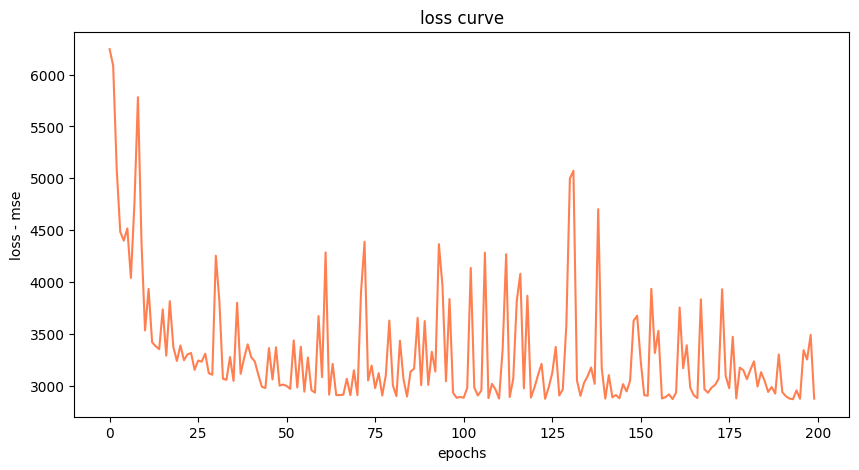

In [37]:
# loss curve
plt.figure(figsize=(10,5))
plt.plot(range(sgd.epochs), sgd.loss_list, color = 'coral')
plt.title('loss curve')
plt.xlabel('epochs')
plt.ylabel('loss - mse')
plt.show()